# Object Tracking Project — Football Player Tracking
## Part 1: Training the Object Detector (SSD)

In previous sessions we covered the concept of Object Tracking and the different tracking algorithms. In this session we move into the hands-on part of the project: **tracking football players**.

The final goal is to detect and track players in a football video across frames, giving each player a **persistent ID**.

### Approach: Tracking by Detection

In this approach we first have an **Object Detector** that, for every frame, finds each object, predicts its class, outputs a bounding box, and produces a confidence score. Then, a tracking algorithm links these objects together across frames.

```text
Video
  │
  ▼
Frame ──► Detection ──► Bounding Box + Class + Confidence
                              │
                              ▼
                          Tracking
                              │
                              ▼
                   Persistent Object IDs
```

Important note: since we're using Tracking by Detection, **training the detector does not require video at all**; a plain image dataset (image + bounding box + class) is enough. Video is only needed at the tracking stage (later notebooks).

### Dataset

For this project we use a football players dataset that is already prepared in **YOLO** format (with `train` / `valid` / `test` splits and a `data.yaml` file). Being in YOLO format doesn't mean it can only be used with YOLO; in this notebook we use the same dataset to train a different detector, **SSD (Single Shot Detector)** (we convert the YOLO annotations to `[xmin, ymin, xmax, ymax]` ourselves).

Overall steps in this notebook:
1. Prepare the dataset and dataloaders
2. Define the SSD300 model and replace its classification head to match our number of classes
3. Train the model with validation, saving the best model
4. Evaluate with the mAP metric
5. Run inference on a sample test image


### Imports and Device Setup

We import the required libraries (OpenCV, NumPy, Pandas, Matplotlib, PyTorch, torchvision) and check whether a GPU is available. All model computation later on will use this `DEVICE` (preferably `cuda`).


In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
import torchvision

In [2]:
torch.cuda.is_available()

True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
DEVICE

device(type='cuda')

### Base Dataset Configuration

Here we set the paths to the `train` / `test` / `valid` folders, the input image size for the model (`TARGET_SIZE = 300x300`, matching SSD300), and the `BATCH_SIZE`.


In [5]:
TARGET_SIZE = (300, 300)
BATCH_SIZE = 32
TRAIN_DIR = 'football_players_detection/train'
TEST_DIR = 'football_players_detection/test'
VAL_DIR = 'football_players_detection/valid'

### Label Map

Since this dataset only has one object class (`Player`), we define a `LABEL_MAP`. Note that we also need to account for the background class, so `NUM_CLASSES = number_of_classes + 1`.


In [6]:
LABEL_MAP = {'Player': 1}
NUM_CLASSES = len(LABEL_MAP) + 1
NUM_CLASSES

2

### `process_data` Function: Reading an Image and Converting Its Annotation

This function reads an image together with its corresponding label file (in YOLO format). The YOLO format is `class, x_center, y_center, width, height` (normalized between 0 and 1). In this function these values are:

1. First converted to absolute pixel coordinates,
2. Then converted to `[xmin, ymin, xmax, ymax]` format (which SSD-style detectors expect),
3. And finally rescaled to match `TARGET_SIZE` (300×300).

The image is also converted from BGR to RGB and turned into a normalized tensor (values between 0 and 1) with channel order `(C, H, W)`. The final output is an `image_tensor` and a `target` dictionary (containing `boxes` and `labels`).


In [7]:
def process_data(idx, all_image_files, images_dir, labels_dir, target_size, label_map):
    
    image_name = all_image_files[idx]
    image_path = os.path.join(images_dir, image_name)
    
    label_name = os.path.splitext(image_name)[0] + '.txt'
    label_path = os.path.join(labels_dir, label_name)

    image = cv2.imread(image_path)
    h_orig, w_orig, _ = image.shape
    
    boxes = []
    labels = []

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                x_center, y_center, width, height = map(float, parts[1:])
                
                x_center_abs = x_center * w_orig
                y_center_abs = y_center * h_orig
                width_abs = width * w_orig
                height_abs = height * h_orig
                
                xmin = x_center_abs - (width_abs / 2)
                ymin = y_center_abs - (height_abs / 2)
                xmax = x_center_abs + (width_abs / 2)
                ymax = y_center_abs + (height_abs / 2)

                xmin_scaled = int((xmin / w_orig) * target_size[0])
                ymin_scaled = int((ymin / h_orig) * target_size[1])
                xmax_scaled = int((xmax / w_orig) * target_size[0])
                ymax_scaled = int((ymax / h_orig) * target_size[1])
                
                if xmax_scaled > xmin_scaled and ymax_scaled > ymin_scaled:
                    boxes.append([xmin_scaled, ymin_scaled, xmax_scaled, ymax_scaled])
                    labels.append(label_map['Player'])

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, target_size)
    image_tensor = torch.tensor(image_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0

    if len(boxes) == 0:
        boxes_tensor = torch.empty((0, 4), dtype=torch.float32)
        labels_tensor = torch.empty((0,), dtype=torch.int64)
    else:
        boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.int64)

    target = {
        'boxes': boxes_tensor,
        'labels': labels_tensor
    }
    
    return image_tensor, target

### Custom Dataset Class

We define a `Dataset` class based on `torch.utils.data.Dataset` that takes the image/label directories and uses `process_data` for every index. `collate_fn` exists because the number of bounding boxes per image varies, so images can't simply be stacked into a batch — instead we return the batch as a tuple.


In [8]:
from torch.utils.data import Dataset

class Dataset(Dataset):
    def __init__(self, data_dir, target_size, label_map):
        self.images_dir = os.path.join(data_dir, 'images')
        self.labels_dir = os.path.join(data_dir, 'labels')
        self.target_size = target_size
        self.label_map = label_map
        self.image_files = [f for f in os.listdir(self.images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        
        return process_data(
            idx=idx,
            all_image_files=self.image_files,
            images_dir=self.images_dir,
            labels_dir=self.labels_dir,
            target_size=self.target_size,
            label_map=self.label_map
        )

def collate_fn(batch):
    return tuple(zip(*batch))

### Building the Train / Test / Validation Datasets

Using the class above, we build three datasets — train, test, and validation — and check the number of samples in each.


In [9]:
train_dataset = Dataset(data_dir=TRAIN_DIR, target_size=TARGET_SIZE, label_map=LABEL_MAP)
len(train_dataset)

10308

In [10]:
test_dataset = Dataset(data_dir=TEST_DIR, target_size=TARGET_SIZE, label_map=LABEL_MAP)
len(test_dataset)

520

In [11]:
val_dataset = Dataset(data_dir=VAL_DIR, target_size=TARGET_SIZE, label_map=LABEL_MAP)
len(val_dataset)

972

### Building the DataLoaders

For each of the three datasets, we build a `DataLoader`. `train_loader` uses `shuffle=True` so the sample order is randomized every epoch. We use the `collate_fn` defined above, and `num_workers` / `pin_memory` are set to speed up data transfer to the GPU.


In [12]:
NUM_WORKERS = 8

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True  
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders created with num_workers = {NUM_WORKERS}")


DataLoaders created with num_workers = 8


### Visualizing a Batch to Sanity-Check the Annotations

Before moving to training, it's a good idea to visualize a few images from `train_loader` along with their bounding boxes to confirm the annotation conversion worked correctly.


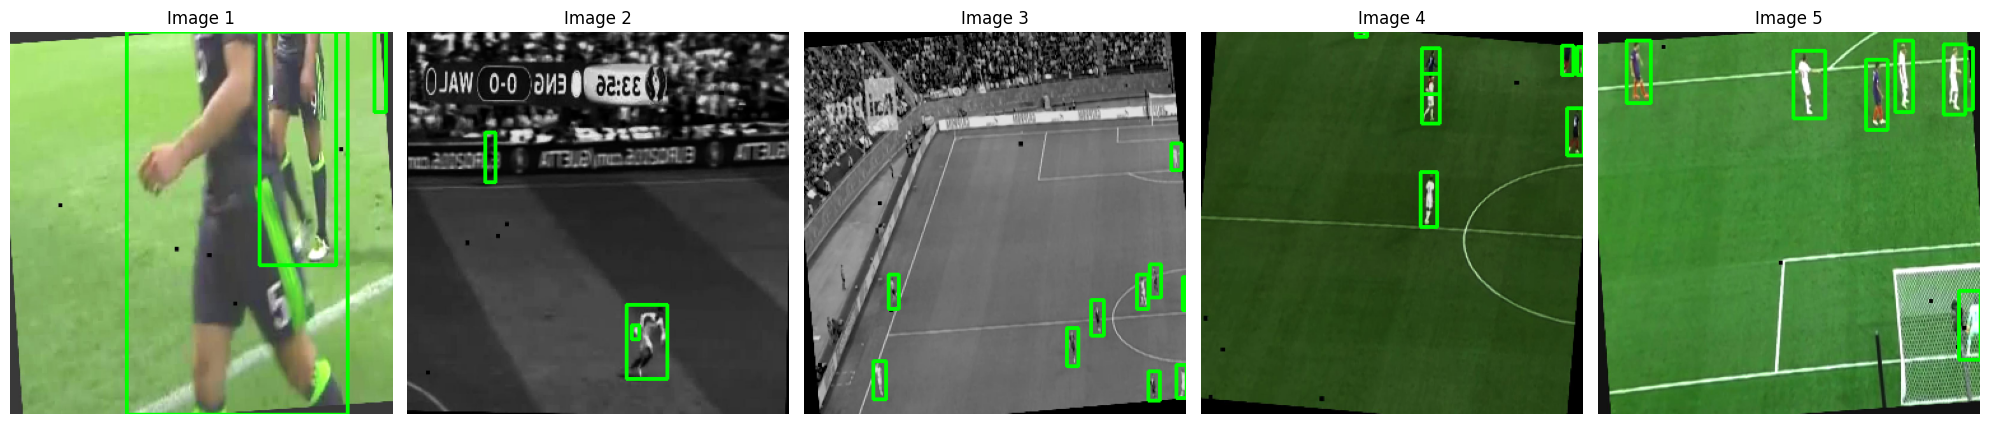

In [13]:
images, targets = next(iter(train_loader))
num_images_to_show = 5

fig, axes = plt.subplots(1, num_images_to_show, figsize=(20, 5))

for i in range(num_images_to_show):
    image = images[i].permute(1, 2, 0).cpu().numpy() * 255
    image = image.astype(np.uint8)

    boxes = targets[i]['boxes'].cpu().numpy()
    labels = targets[i]['labels'].cpu().numpy()

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = map(int, box)
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        
    axes[i].imshow(image)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis('off') 

plt.tight_layout()
plt.show()

### Inspecting Tensor Shapes

We grab another batch and inspect the shape of the image tensor and the content of the `target` for the first sample, to make sure everything matches the model's expected input format.


In [14]:
images, targets = next(iter(train_loader))

In [15]:
images[0].shape

torch.Size([3, 300, 300])

In [16]:
targets[0]

{'boxes': tensor([[  0.,  41., 192., 247.],
         [  0.,   0.,  30., 238.]]),
 'labels': tensor([1, 1])}

## Defining the SSD Model

We use `torchvision.models.detection.ssd300_vgg16` with pretrained weights (pretrained on COCO). By default this model is configured for the COCO classes, so we need to replace its classification head to match our own number of classes (Player + Background).


In [17]:
model = torchvision.models.detection.ssd300_vgg16(
    weights=torchvision.models.detection.SSD300_VGG16_Weights.DEFAULT,
)

### Extracting `in_channels` for Each Feature Map

To rebuild the classification head, we first need to extract the number of input channels for each of the existing layers in `classification_head`.


In [18]:
in_channels = []
for i in range(len(model.head.classification_head.module_list)):
    in_channels.append(model.head.classification_head.module_list[i].in_channels)

In [19]:
in_channels

[512, 1024, 512, 256, 256, 256]

### Number of Anchor Boxes per Location

From the model's `anchor_generator`, we get the number of anchor boxes generated at each spatial location (per feature map). This value is also needed to build the new classification head.


In [20]:
num_anchors = model.anchor_generator.num_anchors_per_location()

In [21]:
num_anchors

[4, 6, 6, 6, 4, 4]

### Replacing the Classification Head

Using the `in_channels` and `num_anchors` obtained above, we build a new `SSDClassificationHead` whose output matches our `NUM_CLASSES` (instead of the COCO classes).


In [22]:
model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES
)

### Defining the Optimizer

We collect the parameters that require training (`requires_grad=True`) and define an `SGD` optimizer with momentum and weight decay.


In [23]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

## Training the Model (Training + Validation)

We train the model for 5 epochs. In each epoch:

* **Training step**: the model runs on `train_loader`, loss is computed, and backpropagation is performed.
* **Validation step**: at the same time, loss is also computed on `val_loader` (without updating weights) so we can monitor performance on unseen data.

Important note: we do **not** save the model at every epoch; the model is only saved to `best_model.pth` when the `validation loss` improves over the previous best value. This way we always keep the **best model** based on validation, not necessarily the last epoch trained.

> ⚠️ **Overfitting note:** in the training results, starting from around epoch 4, the gap between the training loss and the validation loss gradually grows; this is a sign of the onset of overfitting (the model keeps improving on the training data, but its generalization ability doesn't grow at the same rate). Possible remedies: growing the dataset, data augmentation, tuning the learning rate/optimizer, regularization, or using a stronger detector.


In [24]:
epochs = 5
model.to(DEVICE)
model.train()

best_val_loss = float('inf')

for epoch in range(epochs):
    train_loss = 0.0
    # ---- Train ----
    for images, targets in train_loader:
        optimizer.zero_grad()
        
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        loss_dict_train = model(images, targets)
        loss = sum(l for l in loss_dict_train.values())
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

    # ---- Validation ----
    test_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader: 
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            

            loss_dict_test = model(images, targets)
            loss = sum(l for l in loss_dict_test.values())
            test_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss = test_loss / len(val_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_test_loss:.4f}")

    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        torch.save(model, 'best_model.pth')
        print(f"Model improved and saved to best_model.pth with Val Loss: {best_val_loss:.4f}")

Epoch 1/5 | Train Loss: 3.0538 | Val Loss: 2.9851
Model improved and saved to best_model.pth with Val Loss: 2.9851
Epoch 2/5 | Train Loss: 2.4485 | Val Loss: 2.9343
Model improved and saved to best_model.pth with Val Loss: 2.9343
Epoch 3/5 | Train Loss: 2.2575 | Val Loss: 2.7803
Model improved and saved to best_model.pth with Val Loss: 2.7803
Epoch 4/5 | Train Loss: 2.1114 | Val Loss: 2.8532
Epoch 5/5 | Train Loss: 1.9875 | Val Loss: 2.5750
Model improved and saved to best_model.pth with Val Loss: 2.5750


## Evaluating the Model with mAP

One of the most important evaluation metrics in object detection is **mAP (mean Average Precision)**. The `calculate_map` function, using the `torchmetrics` library, compares the model's predictions on a dataloader against ground truth and returns `mAP`, `mAP@50`, and `mAP@75`.


In [54]:
from torchmetrics.detection import MeanAveragePrecision

def calculate_map(model, dataloader, device):
  
    metric = MeanAveragePrecision(box_format='xyxy')
    
    model.eval()
    model.to(device)
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            predictions = model(images)
            

            metric.update(predictions, targets)
            
    results = metric.compute()
    
    print(f"mAP: {results['map'].item():.4f}")
    print(f"mAP@50 (IoU=0.50): {results['map_50'].item():.4f}")
    print(f"mAP@75 (IoU=0.75): {results['map_75'].item():.4f}")

    return results

### Running Evaluation on Test and Train

We load the saved best model (`best_model.pth`) and compute its mAP on both the test set and the train set.

The result of this experiment was **mAP ≈ 42** on the test set, which isn't a great score; compared to the mAP on the training set (around 56), this gap of roughly 10 points is again a sign of the same overfitting we saw in the training section. This shows the SSD detector still has room for improvement (in the later notebooks we train the same dataset with YOLO and compare).


In [55]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load('best_model.pth')

print("\n--- Test Set Evaluation ---")
test_map_results = calculate_map(model, test_loader, DEVICE)

print("\n--- Train Set Evaluation ---")
train_map_results = calculate_map(model, train_loader, DEVICE)


--- Test Set Evaluation ---
mAP: 0.4217
mAP@50 (IoU=0.50): 0.8504
mAP@75 (IoU=0.75): 0.3505

--- Train Set Evaluation ---
mAP: 0.5220
mAP@50 (IoU=0.50): 0.8946
mAP@75 (IoU=0.75): 0.5617


## Testing the Model on a Single Image (Prediction + Confidence Score)

The `predict_on_image` function takes an image, converts it to the model's input format, runs prediction, keeps outputs above a confidence threshold (`confidence_threshold`), and draws the bounding boxes on the original image.

Note: a high confidence score (e.g. 0.97) means the model is confident about a particular prediction, but on its own it's not a good measure of overall model performance; for that we still need to look at mAP and metrics like precision/recall (as we did in the previous section).


In [56]:
def predict_on_image(model, image_path, device, label_map, confidence_threshold=0.4):
    model.eval()
    model.to(device)

    image = cv2.imread(image_path)
        
    image_orig = image.copy()
    h_orig, w_orig, _ = image.shape
    target_size = (300, 300)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, target_size)
    image_tensor = torch.tensor(image_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(image_tensor)

    rev_label_map = {v: k for k, v in label_map.items()}

    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    
    boxes_filtered = boxes[scores >= confidence_threshold].astype(np.int32)
    labels_filtered = labels[scores >= confidence_threshold]
    scores_filtered = scores[scores >= confidence_threshold]
    
    font_scale = 1 
    font_thickness = 3 
    
    for box, label, score in zip(boxes_filtered, labels_filtered, scores_filtered):
        xmin = int((box[0] / target_size[0]) * w_orig)
        ymin = int((box[1] / target_size[1]) * h_orig)
        xmax = int((box[2] / target_size[0]) * w_orig)
        ymax = int((box[3] / target_size[1]) * h_orig)
        
        class_name = rev_label_map.get(label, 'Unknown')
        
        cv2.rectangle(image_orig, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        
        label_text = f"{class_name}: {score:.2f}"
        
        (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
        
        cv2.rectangle(image_orig, (xmin, ymin - h - 10), (xmin + w, ymin), (0, 180, 0), -1)
        
        cv2.putText(image_orig, label_text, (xmin, ymin - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

### Running Prediction on a Test Sample

We run the model on a sample image from the test set and inspect the detection result.

---

With this stage complete, our detector (SSD) has been trained and saved (`best_model.pth`). In the next notebooks (`03-BotSort.ipynb` and `04-ByteTrack.ipynb`) we use this same model as the detector in a **Tracking by Detection** pipeline, and run tracking algorithms (BoT-SORT and ByteTrack) on top of its output.


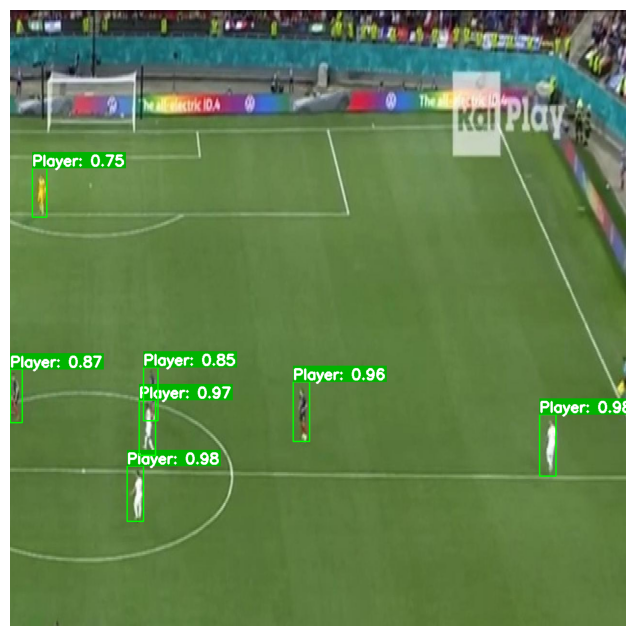

In [57]:
image_path_to_predict = "dataset/test/images/105_pp_jpg.rf.aca5f9a63b27b85c5b568b385326de44.jpg"
predict_on_image(model, image_path_to_predict, DEVICE, LABEL_MAP, confidence_threshold=0.4)